<a href="https://colab.research.google.com/github/phenomenaldatalab/Foundations-of-AI-for-Business/blob/main/Exercise8_Aggregation%20I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Overall: 3 ideas of how to create ensembles
1. Bagging
2. Random Forest
3. Boosting


## Boston Dataset Description(5 mins)
The Boston dataset is a well-known dataset from the 1970s that contains information about housing in Boston. It includes 506 samples with 13 features that describe various aspects of the area, such as crime rate, property tax rate, and the average number of rooms per dwelling. The y variable, 'medv,' represents the median value of owner-occupied homes in thousands of dollars. This dataset is often used in regression tasks to predict housing prices based on these features.

You should download 'Boston.csv' from the drive and upload it in 'Files'

Bagging Model MSE: 9.56
Random Forest Model MSE: 9.62
Boosting Model MSE: 7.33


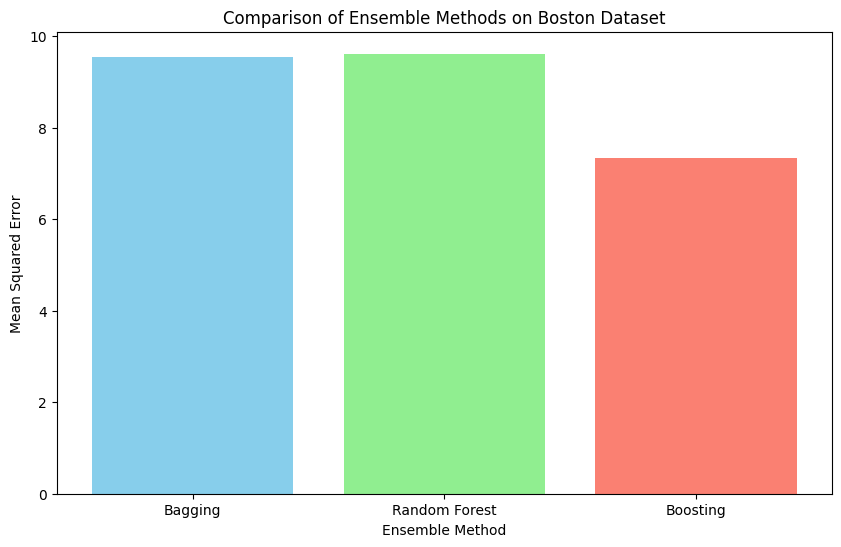

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load the Boston dataset
data = pd.read_csv('/content/Boston.csv')

# Update the feature and target variables based on the correct column name for the target ('medv')
X = data.drop(columns=['medv', 'Unnamed: 0'])
y = data['medv']

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 1. Bagging (Bootstrap Aggregating)
bagging_model = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=100, random_state=42)
bagging_model.fit(X_train, y_train)
bagging_predictions = bagging_model.predict(X_test)
bagging_mse = mean_squared_error(y_test, bagging_predictions)
print(f"Bagging Model MSE: {bagging_mse:.2f}")

# 2. Random Forest (Training on different subsets of attributes)
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)
random_forest_predictions = random_forest_model.predict(X_test)
random_forest_mse = mean_squared_error(y_test, random_forest_predictions)
print(f"Random Forest Model MSE: {random_forest_mse:.2f}")

# 3. Boosting (AdaBoost)
boosting_model = AdaBoostRegressor(estimator=DecisionTreeRegressor(), n_estimators=100, random_state=42)
boosting_model.fit(X_train, y_train)
boosting_predictions = boosting_model.predict(X_test)
boosting_mse = mean_squared_error(y_test, boosting_predictions)
print(f"Boosting Model MSE: {boosting_mse:.2f}")

# Visualizing the performance of different ensemble methods
models = ['Bagging', 'Random Forest', 'Boosting']
mses = [bagging_mse, random_forest_mse, boosting_mse]

plt.figure(figsize=(10, 6))
plt.bar(models, mses, color=['skyblue', 'lightgreen', 'salmon'])
plt.xlabel('Ensemble Method')
plt.ylabel('Mean Squared Error')
plt.title('Comparison of Ensemble Methods on Boston Dataset')
plt.show()


# Breakdown: Bagging/Random Forest/Boosting

## Idea 1: Bagging 10 mins

Bagging was to train similar learners on different subsets of the data [bootstrap].
This is a cheap way to create a diverse set of learners out of only one type of learner (say, decision tree regressor).
The most common way of doing this is "bagging" (Breiman 1996), which works by training learners on subsets
of the original dataset generated by sampling with replacement.
The averaging step helps to reduce variance and improve model stability. This helps to reduce overfitting and increase the model's generalization ability.


### Exercise: Averaging in Bagging
- You need to fill in the blank of the code. Hint: Consider averaging

MSE from bagging: 16.343761814451984


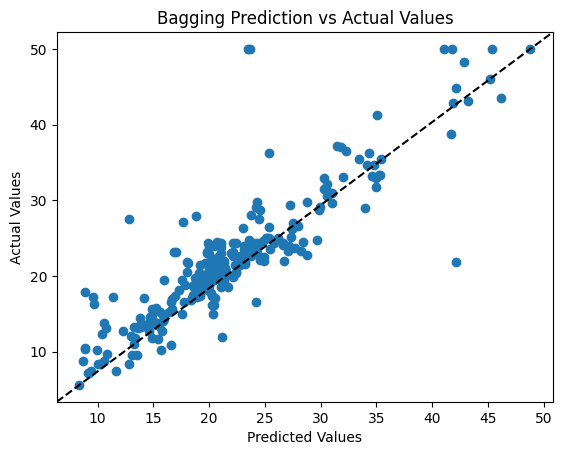

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Load Boston dataset
data = pd.read_csv('Boston.csv').drop('Unnamed: 0', axis=1).dropna()
X = data.drop('medv', axis=1)
y = data['medv']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, random_state=0)
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# Function to bootstrap a decision tree
def bootstrap_decision_tree(X_train, num_samples=253):
    indices = np.random.choice(X_train.index, num_samples, replace=True)
    X = X_train.iloc[indices]
    y = y_train.iloc[indices]
    bootstrap_dt_regr = DecisionTreeRegressor(random_state=1)
    bootstrap_dt_regr.fit(X, y)
    pred = bootstrap_dt_regr.predict(X_test)
    return pred

# Create predictions using bagging
pred_list = []
num_bag = 5000
for _ in range(num_bag):
    pred_return = bootstrap_decision_tree(X_train)
    pred_list.append(pred_return)

# Convert predictions to numpy array
pred_list = np.array(pred_list)

# Student Exercise: Calculate the average of predictions

# Calculate the average of predictions to illustrate the concept of ensemble averaging

##########################################################################################################################
# Calculate the average of predictions (ensemble averaging)
pred_avg = pred_list.sum(axis=0) / num_bag #the answer is (num_bag)
# This is the answer: pred_avg = pred_list.sum(axis=0) / num_bag
##########################################################################################################################

print('MSE from bagging:', mean_squared_error(pred_avg, y_test))

# Plotting predictions vs actual values
plt.scatter(pred_avg, y_test, label='medv')
plt.plot([0, 1], [0, 1], '--k', transform=plt.gca().transAxes)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Bagging Prediction vs Actual Values')
plt.show()


### Bootstrap Visualization

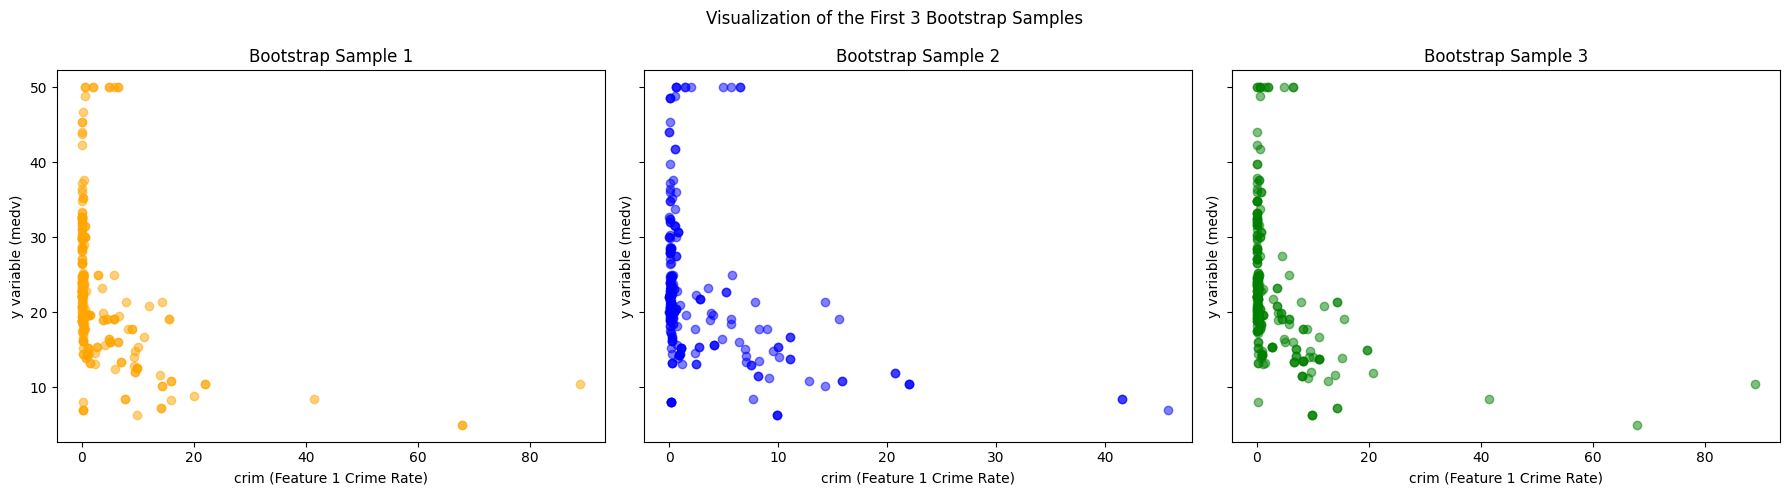

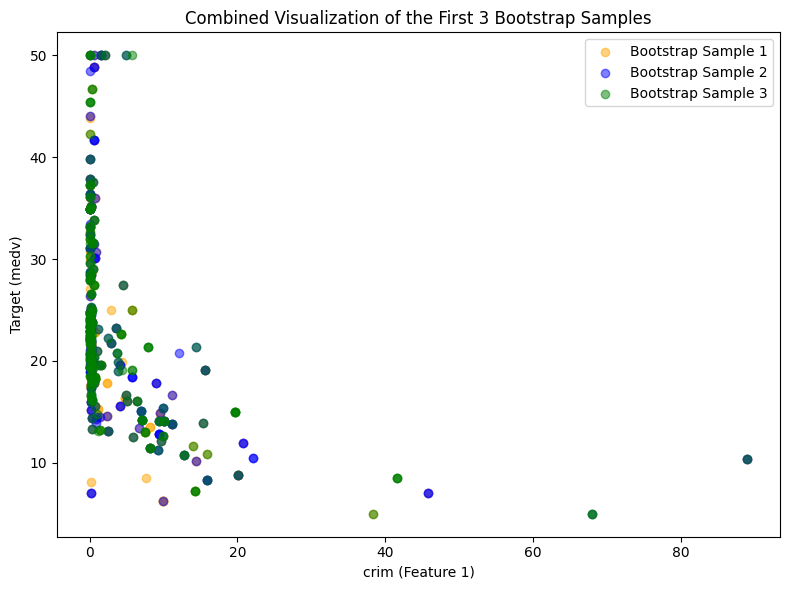

MSE from bagging: 16.4713616755287


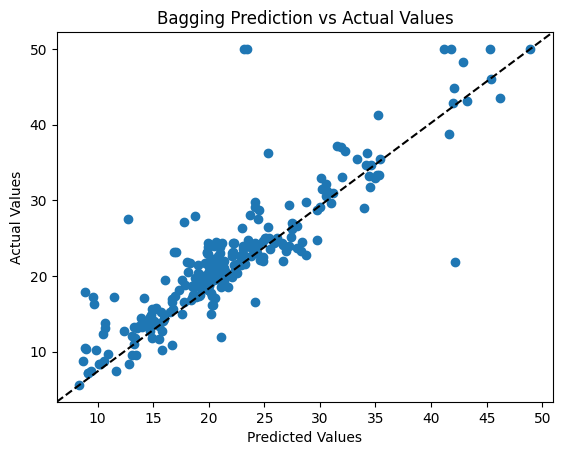

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree

from sklearn.metrics import mean_squared_error

# Load Boston dataset
data = pd.read_csv('Boston.csv').drop('Unnamed: 0', axis=1).dropna()
X = data.drop('medv', axis=1)
y = data['medv']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, random_state=0)
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# Function to bootstrap a decision tree
def bootstrap_decision_tree(X_train, num_samples=253):
    indices = np.random.choice(X_train.index, num_samples, replace=True)
    X = X_train.iloc[indices]
    y = y_train.iloc[indices]
    bootstrap_dt_regr = DecisionTreeRegressor(random_state=1)
    bootstrap_dt_regr.fit(X, y)
    pred = bootstrap_dt_regr.predict(X_test)
    return pred, X, y

# Visualize the first 3 bootstrap samples
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = ['orange', 'blue', 'green']
for i in range(3):
    _, X_bootstrap, y_bootstrap = bootstrap_decision_tree(X_train)
    feature_name = X_train.columns[0]
    axes[i].scatter(X_bootstrap.iloc[:, 0], y_bootstrap, alpha=0.5, color=colors[i])
    axes[i].set_title(f'Bootstrap Sample {i+1}')
    axes[i].set_xlabel(f'{feature_name} (Feature 1 Crime Rate)')
    axes[i].set_ylabel('y variable (medv)')
plt.suptitle('Visualization of the First 3 Bootstrap Samples')
plt.tight_layout()
plt.show()

# Visualize all bootstrap samples together
fig, ax = plt.subplots(figsize=(8, 6))
for i in range(3):
    _, X_bootstrap, y_bootstrap = bootstrap_decision_tree(X_train)
    ax.scatter(X_bootstrap.iloc[:, 0], y_bootstrap, alpha=0.5, color=colors[i], label=f'Bootstrap Sample {i+1}')
feature_name = X_train.columns[0]
ax.set_xlabel(f'{feature_name} (Feature 1)')
ax.set_ylabel('Target (medv)')
ax.set_title('Combined Visualization of the First 3 Bootstrap Samples')
ax.legend()
plt.tight_layout()
plt.show()

# Create predictions using bagging
pred_list = []
num_bag = 5000
for _ in range(num_bag):
    pred_return, _, _ = bootstrap_decision_tree(X_train)
    pred_list.append(pred_return)

# Convert predictions to numpy array
pred_list = np.array(pred_list)

# Calculate the average of predictions (ensemble averaging)
pred_avg = pred_list.sum(axis=0) / num_bag

print('MSE from bagging:', mean_squared_error(pred_avg, y_test))

# Plotting predictions vs actual values
plt.scatter(pred_avg, y_test, label='medv')
plt.plot([0, 1], [0, 1], '--k', transform=plt.gca().transAxes)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Bagging Prediction vs Actual Values')
plt.show()




### Visualization of the First 3 Bootstrap Sample Trees (max_depth=2 or 10)

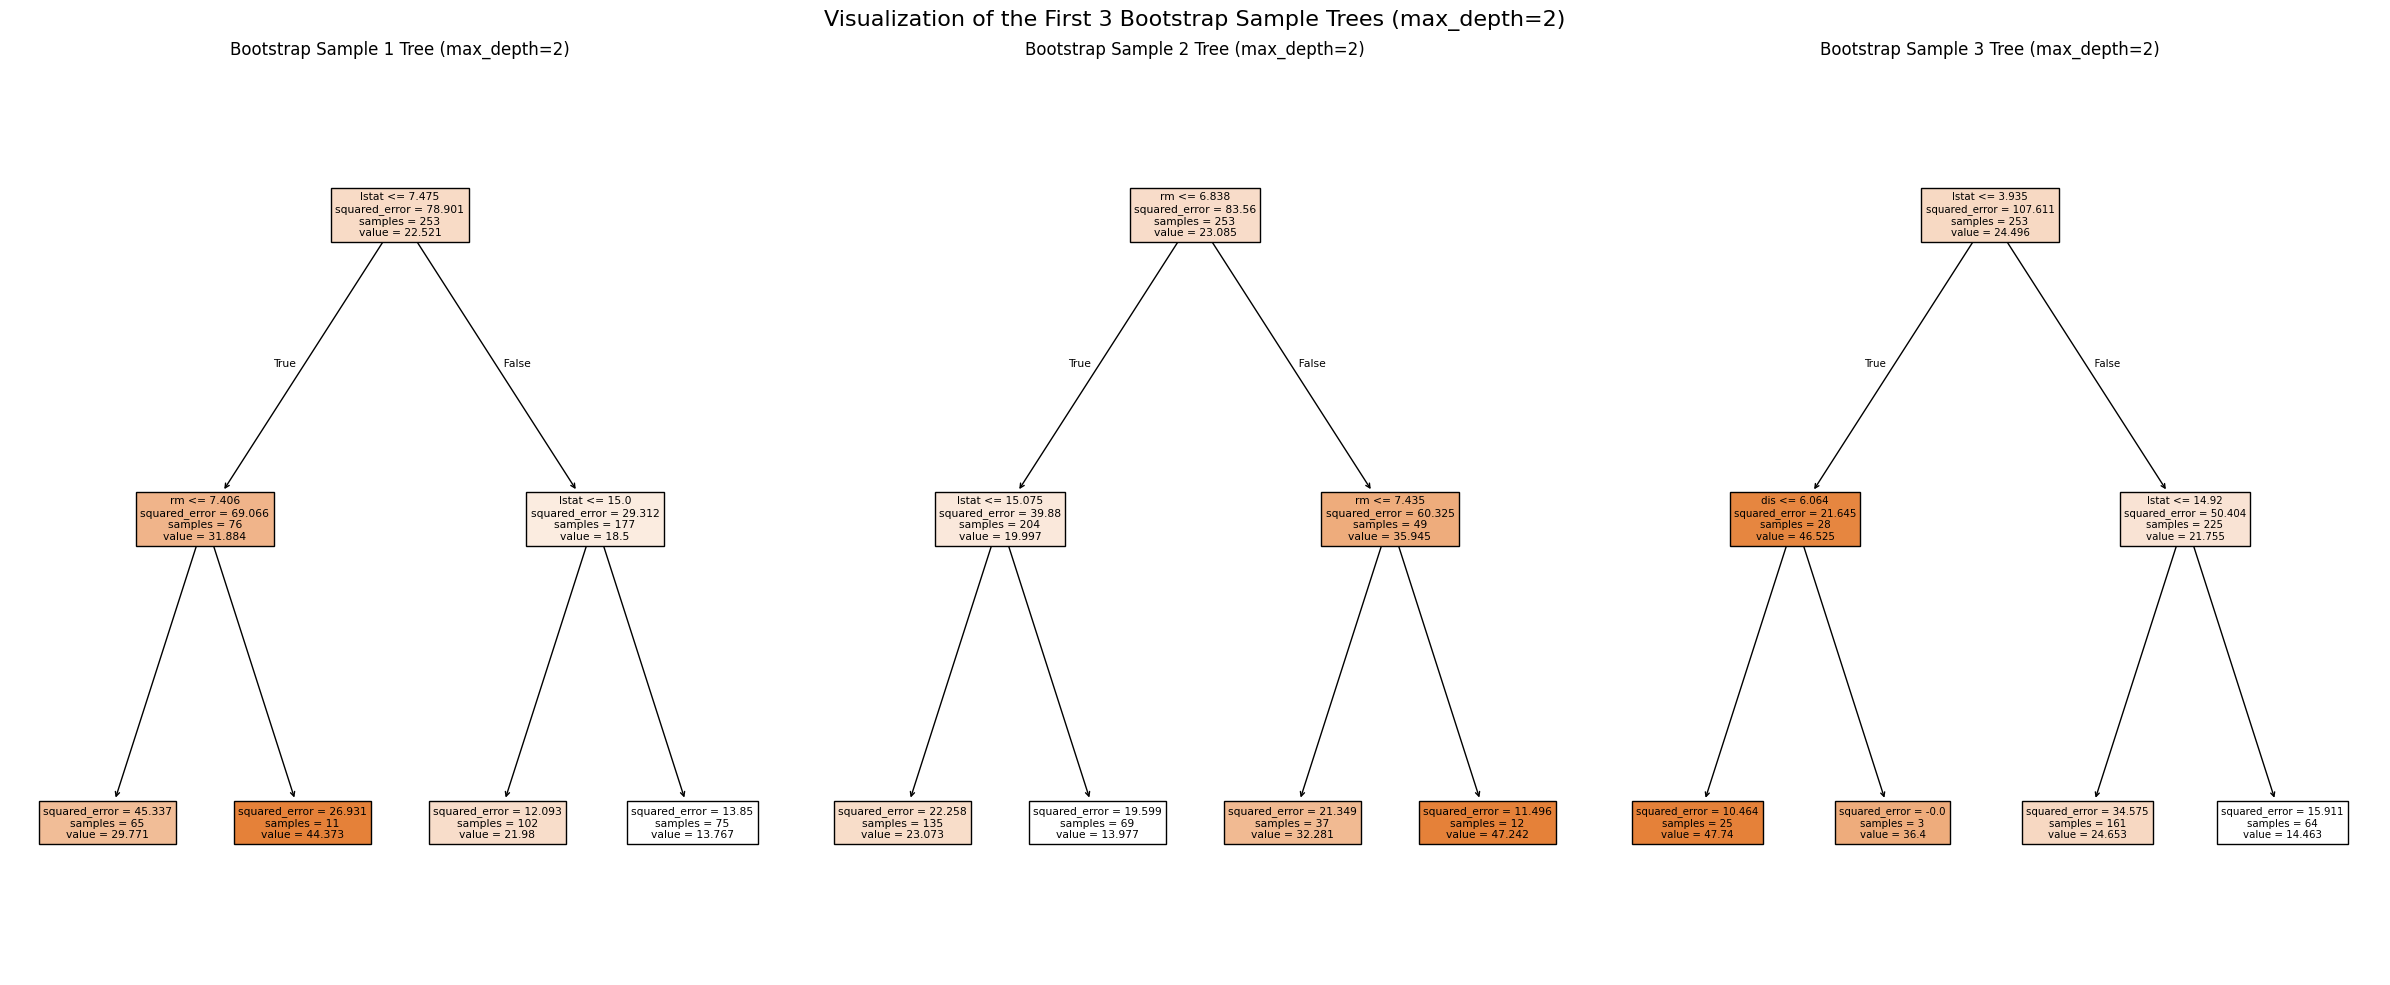

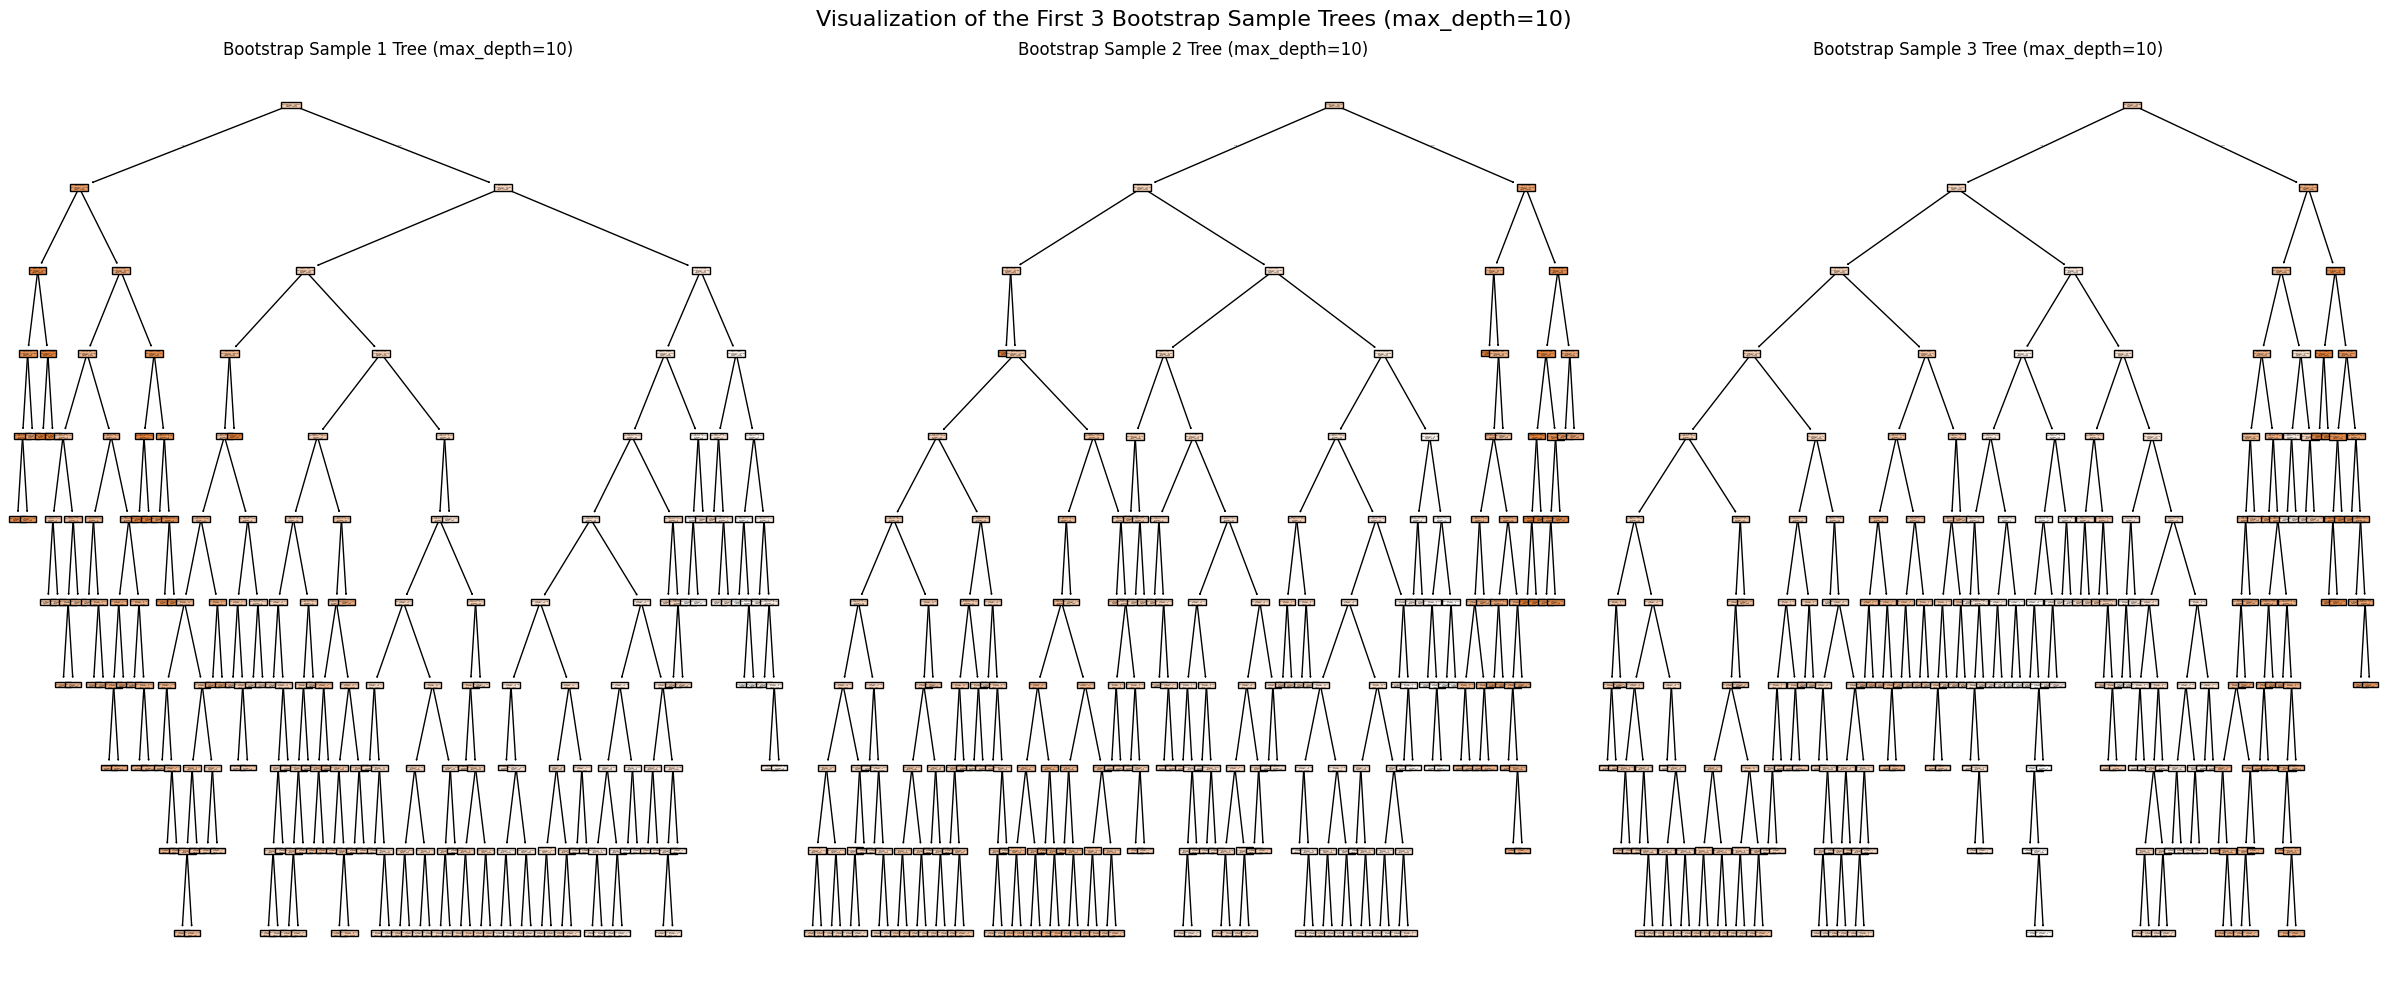

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error

# Load Boston dataset
data = pd.read_csv('Boston.csv').drop('Unnamed: 0', axis=1).dropna()
X = data.drop('medv', axis=1)
y = data['medv']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, random_state=0)
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# Function to bootstrap a decision tree with specified max_depth
def bootstrap_decision_tree(X_train, num_samples=253, max_depth=2):
    indices = np.random.choice(X_train.index, num_samples, replace=True)
    X = X_train.iloc[indices]
    y = y_train.iloc[indices]
    bootstrap_dt_regr = DecisionTreeRegressor(random_state=1, max_depth=max_depth)
    bootstrap_dt_regr.fit(X, y)
    return bootstrap_dt_regr, X, y

# Plotting the first 3 bootstrap sample trees with max_depth=2
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

for i in range(3):
    bootstrap_dt_regr, _, _ = bootstrap_decision_tree(X_train, max_depth=2)
    plot_tree(bootstrap_dt_regr, filled=True, ax=axes[i], feature_names=X_train.columns)
    axes[i].set_title(f'Bootstrap Sample {i + 1} Tree (max_depth=2)')

plt.suptitle('Visualization of the First 3 Bootstrap Sample Trees (max_depth=2)', fontsize=16)
plt.tight_layout()
plt.show()

# Plotting the first 3 bootstrap sample trees with max_depth=10
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

for i in range(3):
    bootstrap_dt_regr, _, _ = bootstrap_decision_tree(X_train, max_depth=10)
    plot_tree(bootstrap_dt_regr, filled=True, ax=axes[i], feature_names=X_train.columns)
    axes[i].set_title(f'Bootstrap Sample {i + 1} Tree (max_depth=10)')

plt.suptitle('Visualization of the First 3 Bootstrap Sample Trees (max_depth=10)', fontsize=16)
plt.tight_layout()
plt.show()


## Idea 2: Random Forest 10 mins

Grushka Cockayne, Jose, and Lichtendahl (2017) model crowds as random forests.
1. Using bagging can be likened to hiring 20 financial statement analysts, all of whom have expertise solely in financial statements, to evaluate a company with new bio-technology.
  - These analysts may be heavily influenced by strong predictors, such as the return on assets (ROA) in the financial statements, and may overlook other factors that could better reveal the company’s potential.
  - The strong predictor in the above graph from the boston dataset are **LSTAT (percentage of lower status of the population)** and **RM (average number of rooms per dwelling)**.

  - As a result, the predictions generated by bagging tend to be highly correlated.

2. In contrast, random forests are akin to hiring 20 experts **from diverse fields**, such as macroeconomics, law, and biology. While these experts may observe similar data, they build different models (the graph of Random Forest) because learning is an inherently idiosyncratic process. This diversity in perspectives results in predictions that are less correlated, more varied, and better able to cancel out errors.

['crim' 'nox' 'rad' 'black']
['black' 'lstat' 'chas' 'rad']
['lstat' 'dis' 'rm' 'nox']


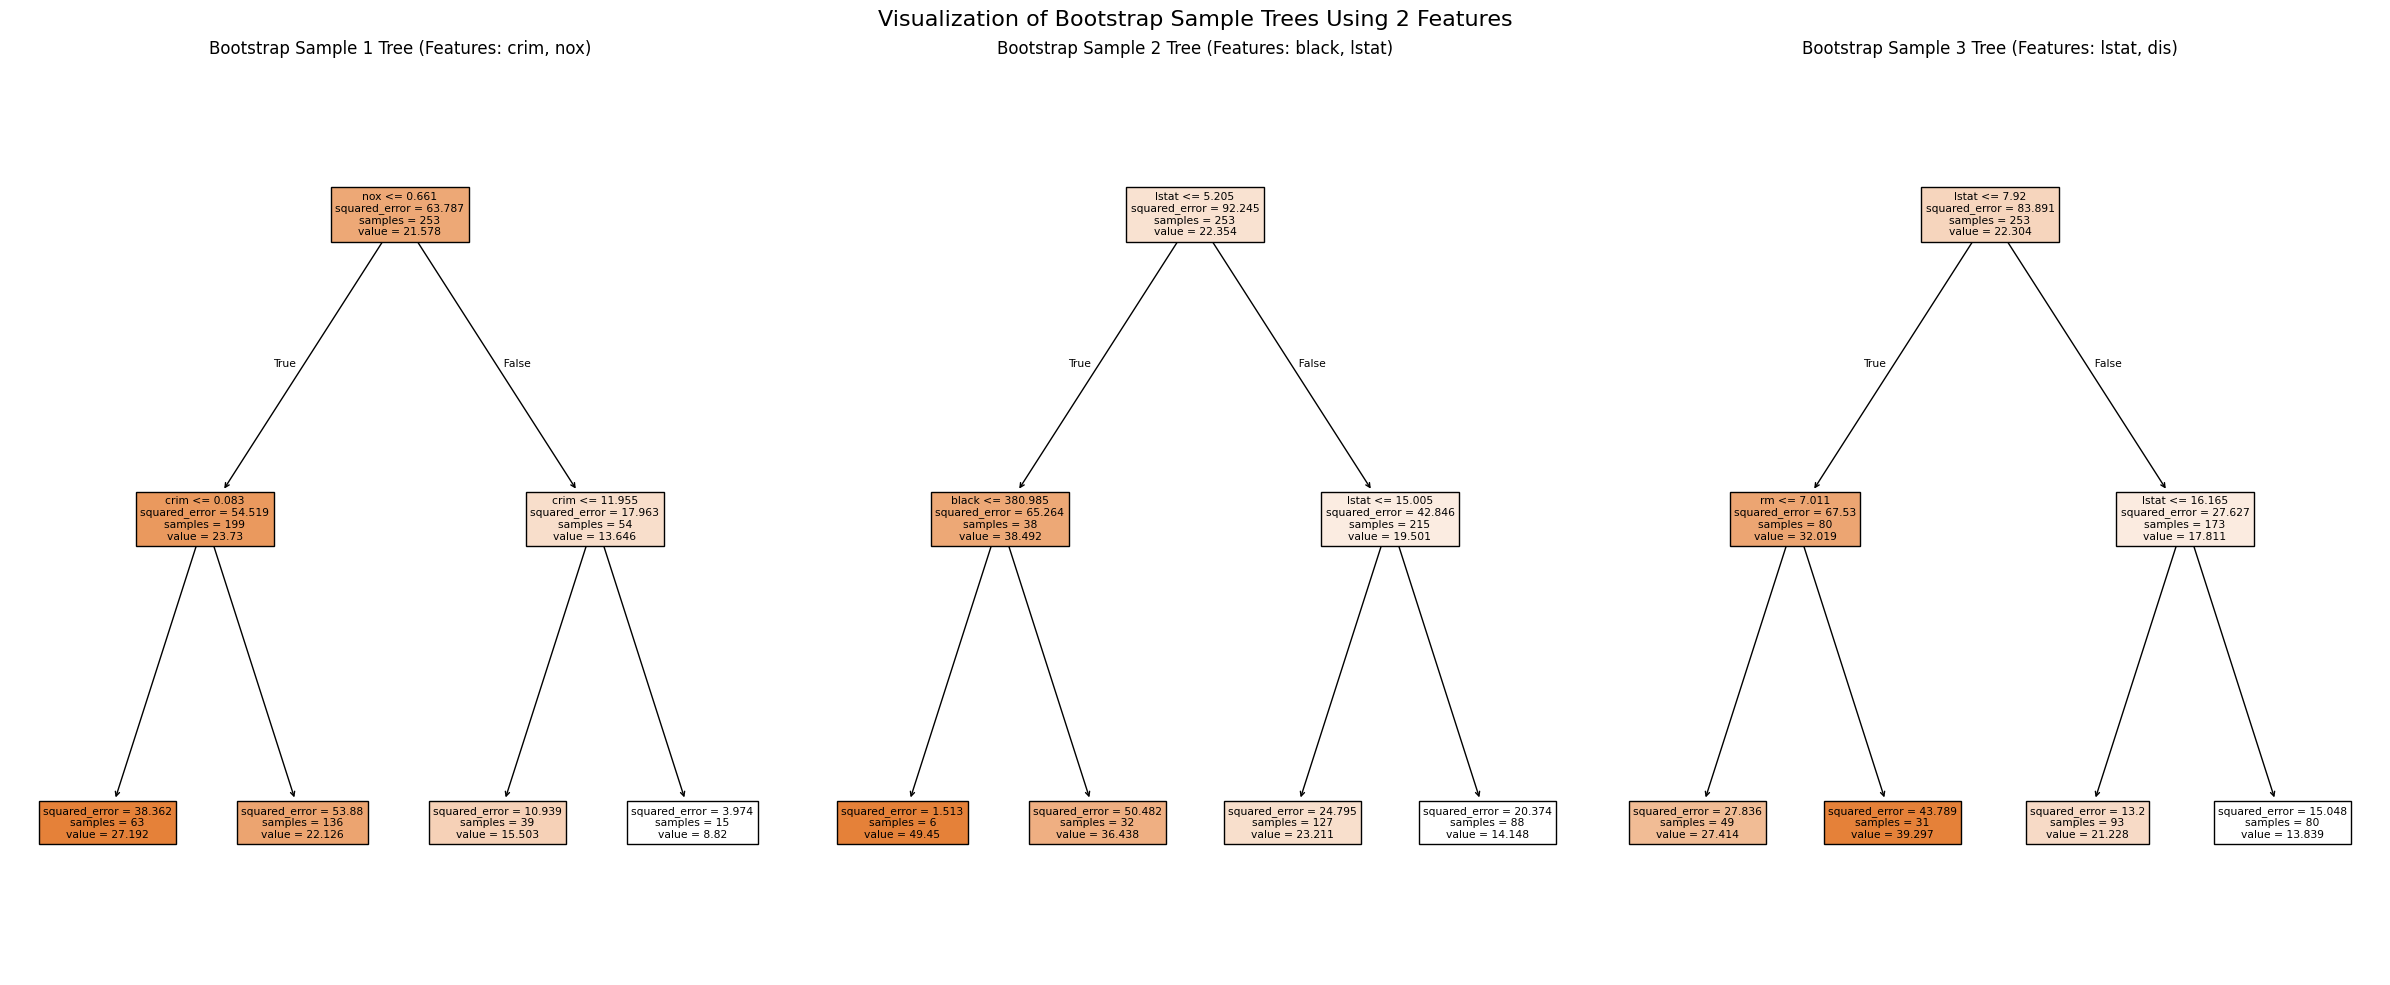

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error

# Load Boston dataset
data = pd.read_csv('Boston.csv').drop('Unnamed: 0', axis=1).dropna()
X = data.drop('medv', axis=1)
y = data['medv']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, random_state=0)
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# Function to bootstrap a decision tree using only 2 features
def bootstrap_decision_tree_two_features(X_train, y_train, num_samples=253, max_depth=2):
    indices = np.random.choice(X_train.index, num_samples, replace=True)
    X = X_train.iloc[indices]
    y = y_train.iloc[indices]

    # Randomly choose 2 features
    chosen_features = np.random.choice(X.columns, size=4, replace=False)
    X_two_features = X[chosen_features]
    print(chosen_features)

    bootstrap_dt_regr = DecisionTreeRegressor(random_state=1, max_depth=max_depth)
    bootstrap_dt_regr.fit(X_two_features, y)
    return bootstrap_dt_regr, chosen_features

# Plotting the first 3 bootstrap sample trees using 2 features
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

for i in range(3):
    bootstrap_dt_regr, chosen_features = bootstrap_decision_tree_two_features(X_train, y_train)

    # Plot each decision tree using only 2 features
    plot_tree(bootstrap_dt_regr, feature_names=chosen_features, filled=True, ax=axes[i])
    axes[i].set_title(f'Bootstrap Sample {i + 1} Tree (Features: {chosen_features[0]}, {chosen_features[1]})')

plt.suptitle('Visualization of Bootstrap Sample Trees Using 2 Features', fontsize=16)
plt.tight_layout()
plt.show()


## Idea 3: Boosting 10 mins

### Introduction to Boosting

Boosting is a powerful machine learning technique that improves the performance of weak learners by training them sequentially. Unlike methods like bagging or random forests, where learners work independently and in parallel, boosting works by placing these learners **in a sequence**. In this way, each subsequent learner focuses on correcting the mistakes made by the previous ones. This approach was first introduced by Schapire (1990) and later refined into AdaBoost (Freund & Schapire, 1996). In AdaBoost, each learner is trained on data that assigns more weight to previously misclassified examples, making the model more robust with each iteration.



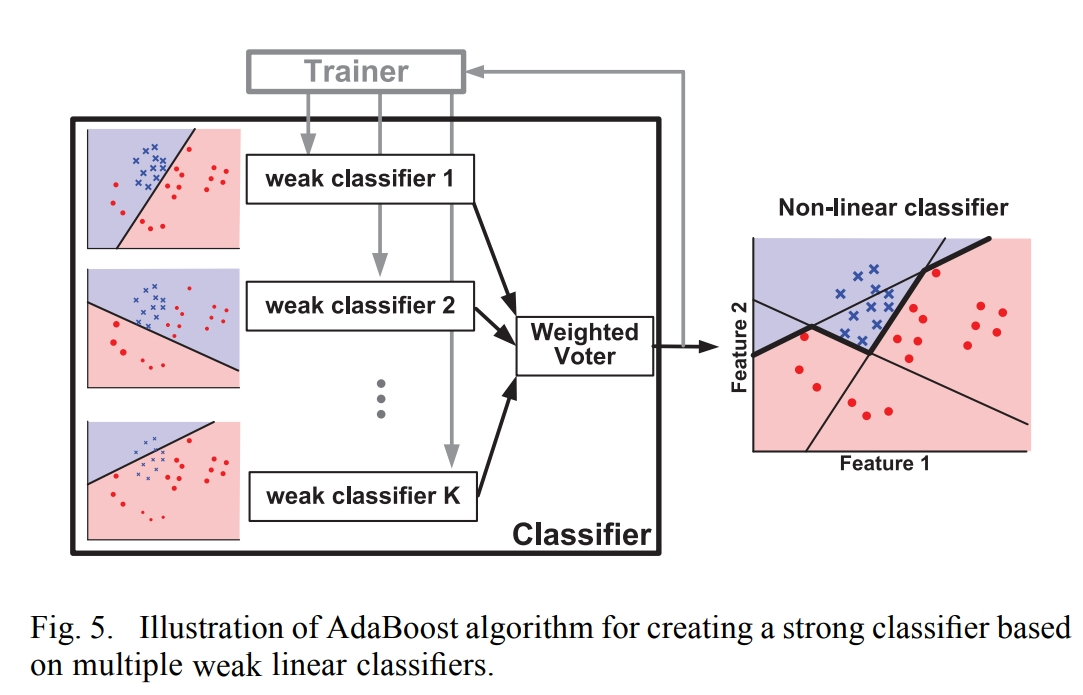

Wang Z, Zhang J, Verma N. Realizing Low-Energy Classification Systems by Implementing Matrix Multiplication Directly Within an ADC. IEEE Trans Biomed Circuits Syst. 2015 Dec;9(6):825-37. doi: 10.1109/TBCAS.2015.2500101. PMID: 26849205.

### Discussion Question

**How might you design an organizational structure that mirrors the principles of boosting?**
- Consider how departments or teams could be organized to sequentially improve performance.
- What strategies could you implement to ensure effective communication and learning between teams, so errors are not repeated but corrected?

# XGBoost 10 mins



### Learning Rate in XGBoost

One of the key features that make XGBoost more effective than traditional boosting methods is the **learning rate**. The learning rate is a hyperparameter that controls how much each weak learner contributes to the final model. Specifically, after each tree is built, the learning rate scales down the contribution of that tree to the overall prediction. By using a smaller learning rate, the model makes smaller updates and takes more gradual steps towards minimizing the loss function, which reduces the risk of overfitting.

### Discussion Questions

Can you think of business scenarios where adjusting the learning rate would be crucial for improving the prediction accuracy?